HEART FAILURE CLINICAL RECORDS ANALYSIS

First 5 rows:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4 

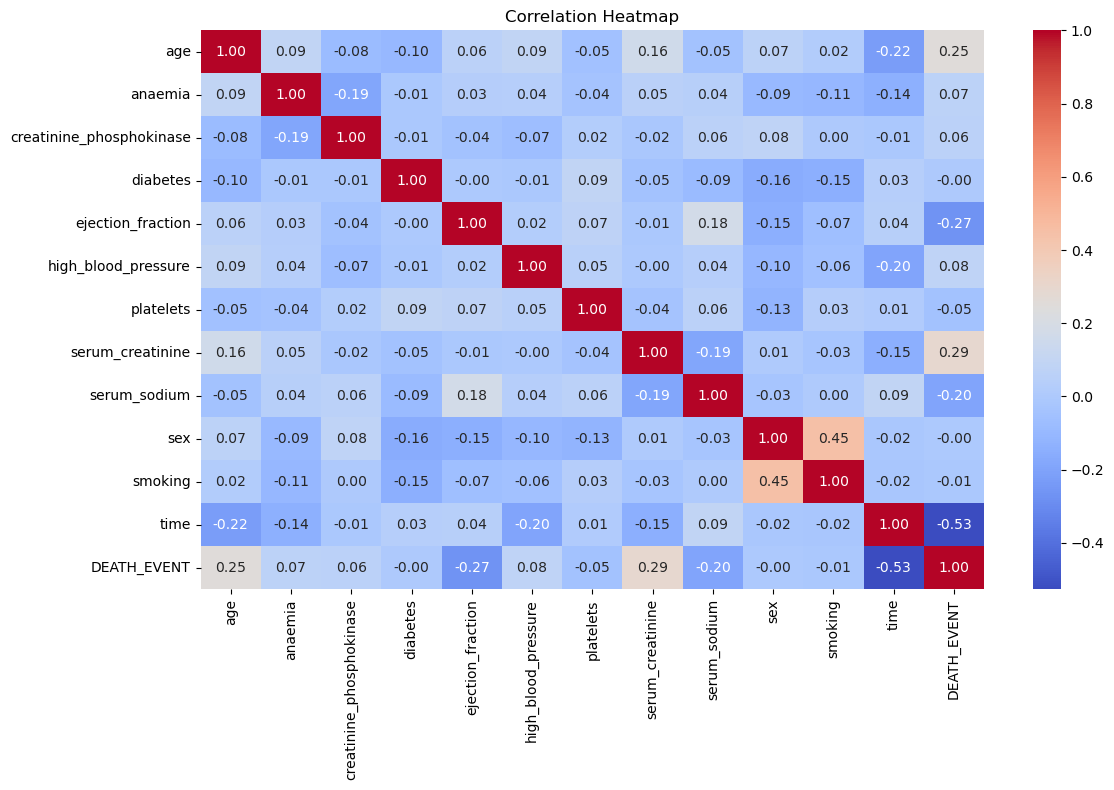


Features shape: (299, 12)
Target shape: (299,)

Training set shape: (239, 12)
Testing set shape : (60, 12)

Scaling completed.

KNN CLASSIFICATION

Best parameters found:
{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}

KNN Evaluation Results:
Accuracy          : 0.7000
Precision         : 0.5714
Recall            : 0.2105
F1-score          : 0.3077
ROC-AUC           : 0.8004
Average Precision : 0.5952

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.93      0.81        41
           1       0.57      0.21      0.31        19

    accuracy                           0.70        60
   macro avg       0.64      0.57      0.56        60
weighted avg       0.67      0.70      0.65        60



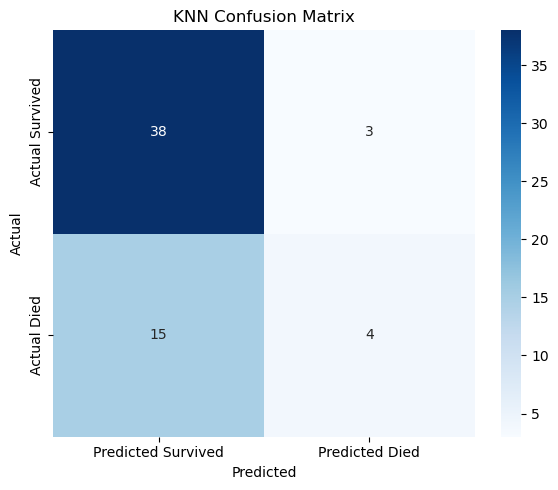

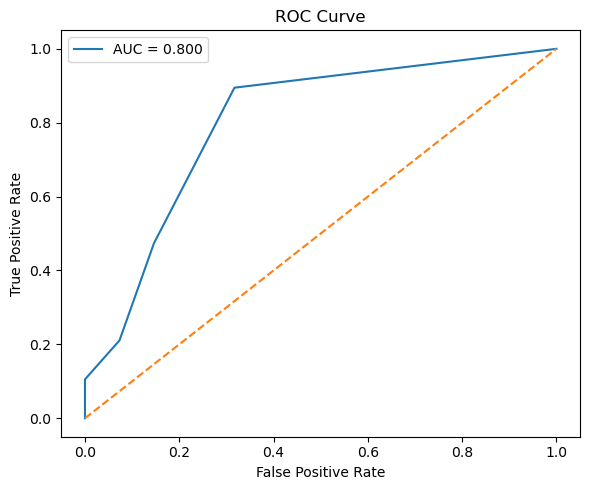

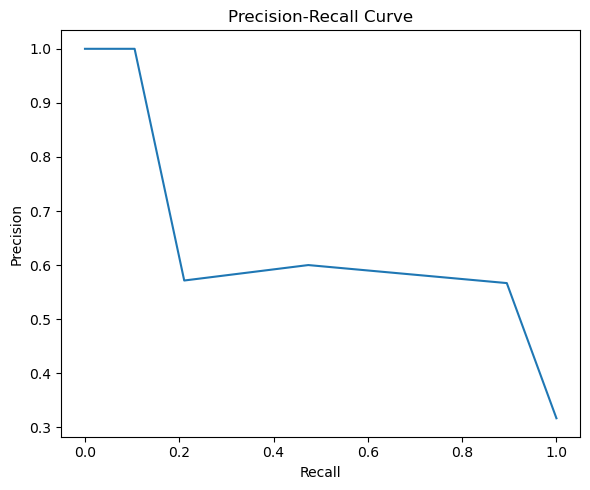


K-MEANS CLUSTERING


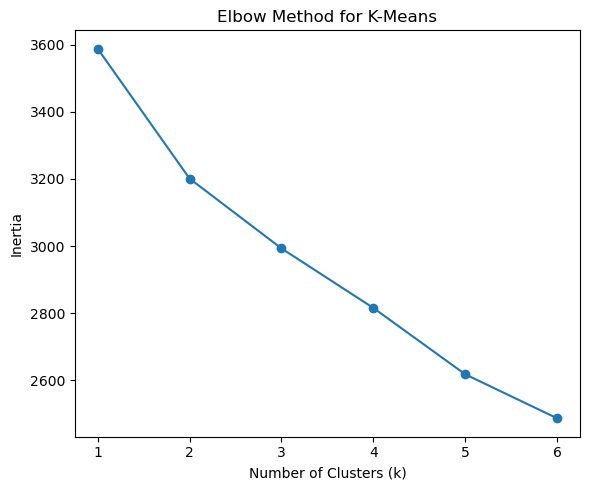

k = 2, Silhouette Score = 0.1179
k = 3, Silhouette Score = 0.1053
k = 4, Silhouette Score = 0.1049
k = 5, Silhouette Score = 0.1084
k = 6, Silhouette Score = 0.1053

Best number of clusters based on silhouette score: 2


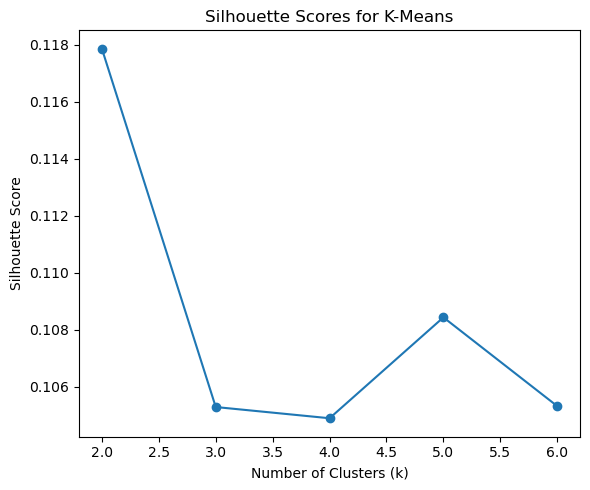


Cluster counts:
Cluster
0    192
1    107
Name: count, dtype: int64

Cluster mean summary:
               age   anaemia  creatinine_phosphokinase  diabetes  \
Cluster                                                            
0        61.472224  0.395833                643.395833  0.354167   
1        59.688477  0.495327                471.383178  0.532710   

         ejection_fraction  high_blood_pressure      platelets  \
Cluster                                                          
0                36.552083             0.307292  253473.065000   
1                40.831776             0.429907  281095.535234   

         serum_creatinine  serum_sodium       sex   smoking        time  \
Cluster                                                                   
0                1.404375    136.520833  1.000000  0.479167  129.338542   
1                1.375047    136.813084  0.018692  0.037383  131.915888   

         DEATH_EVENT  
Cluster               
0           0.322917  


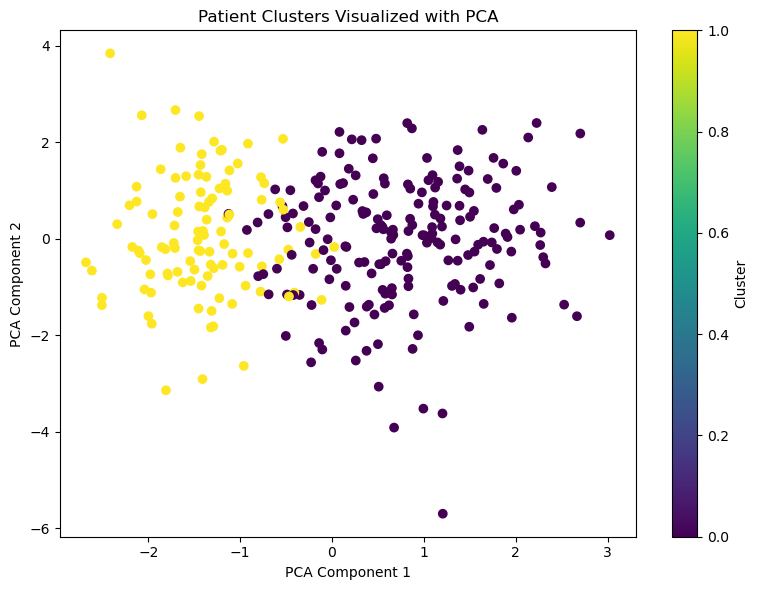


INTERPRETATION
Highest risk cluster: Cluster 0 with mortality rate 32.29%
Lowest risk cluster : Cluster 1 with mortality rate 31.78%

Saved clustered dataset as: heart_failure_with_clusters.csv

Done successfully.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    silhouette_score
)


# 1. LOAD DATA

file_path = "../data/heart_failure_clinical_records_dataset.csv"
df = pd.read_csv(file_path)

print("=" * 60)
print("HEART FAILURE CLINICAL RECORDS ANALYSIS")
print("=" * 60)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["DEATH_EVENT"].value_counts())

print("\nTarget distribution (%):")
print((df["DEATH_EVENT"].value_counts(normalize=True) * 100).round(2))

print("\nSummary statistics:")
print(df.describe())


# 2. CORRELATION HEATMAP

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# 3. FEATURES AND TARGET

X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


# 4. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)


# 5. FEATURE SCALING

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_all = scaler.fit_transform(X)

print("\nScaling completed.")


# 6. KNN CLASSIFICATION

print("\n" + "=" * 60)
print("KNN CLASSIFICATION")
print("=" * 60)

param_grid = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_knn = grid_search.best_estimator_

print("\nBest parameters found:")
print(grid_search.best_params_)

# Predictions
y_pred = best_knn.predict(X_test_scaled)
y_prob = best_knn.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

print("\nKNN Evaluation Results:")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-score          : {f1:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"Average Precision : {avg_precision:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# 7. CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Survived", "Predicted Died"],
    yticklabels=["Actual Survived", "Actual Died"]
)
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# 8. ROC CURVE

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


# 9. PRECISION-RECALL CURVE

pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(pr_recall, pr_precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()


# 10. K-MEANS CLUSTERING

print("\n" + "=" * 60)
print("K-MEANS CLUSTERING")
print("=" * 60)

# Elbow method
inertias = []
k_range = range(1, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_all)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.tight_layout()
plt.show()

# Silhouette scores
silhouette_scores = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled_all)
    score = silhouette_score(X_scaled_all, cluster_labels)
    silhouette_scores.append(score)
    print(f"k = {k}, Silhouette Score = {score:.4f}")

best_k = list(k_values)[np.argmax(silhouette_scores)]
print(f"\nBest number of clusters based on silhouette score: {best_k}")

plt.figure(figsize=(6, 5))
plt.plot(list(k_values), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means")
plt.tight_layout()
plt.show()

# Final KMeans
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled_all)

df["Cluster"] = clusters

print("\nCluster counts:")
print(df["Cluster"].value_counts().sort_index())

print("\nCluster mean summary:")
print(df.groupby("Cluster").mean(numeric_only=True))

cluster_mortality = df.groupby("Cluster")["DEATH_EVENT"].mean() * 100

print("\nMortality rate (%) by cluster:")
print(cluster_mortality.round(2))


# 11. PCA VISUALIZATION

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_all)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis")
plt.title("Patient Clusters Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


# 12. INTERPRETATION

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)

highest_risk_cluster = cluster_mortality.idxmax()
lowest_risk_cluster = cluster_mortality.idxmin()

print(
    f"Highest risk cluster: Cluster {highest_risk_cluster} "
    f"with mortality rate {cluster_mortality[highest_risk_cluster]:.2f}%"
)

print(
    f"Lowest risk cluster : Cluster {lowest_risk_cluster} "
    f"with mortality rate {cluster_mortality[lowest_risk_cluster]:.2f}%"
)


# 13. SAVE OUTPUT

df.to_csv('../data/heart_failure_with_clusters.csv', index=False)
print("\nSaved clustered dataset as: heart_failure_with_clusters.csv")

print("\nDone successfully.")

